## Spatial Aggregation Using Cubes

In this notebook, the objective is to use the spatial units available from Paul's study to aggregate the climate data. This will allow us to store both the mobility/migration information and the climate information at the same spatial scale. Hence, easy and smooth analysis.




## Data Testing

In [1]:
import os
import geopandas as gpd
from pathlib import Path

# For Zonal Stats 
import xvec
import xproj

import xarray as xr
import rioxarray as rio
import zarr
import time
import psutil
import pandas as pd
import glob
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm as cm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
%load_ext autoreload
%autoreload 2
from zarr_local import plot_sahel_ds, example_dataset_path, check_time_steps
# call functions or re-import as needed

Imports OK
  - xarray: 2025.11.0
  - numpy:  2.4.2
  - pandas: 3.0.0
  - zarr:   3.1.5


In [3]:
# data_path = r"/home/kzakir/dvcube/test/zarr_cube/data"
# # read the zarr dataset
# ds = xr.open_zarr(os.path.join(data_path, "fapar_try.zarr"), consolidated=True)
# ds
# read all the files in the ndvi/yeaar directory (only 2010 to 2018)
main_path_ndvi = r"/data/dv-data/cdo_processed/NDVI/"
# folders only from 2010 to 2018
folders = [p for p in Path(main_path_ndvi).iterdir() if p.is_dir() and p.name.isdigit() and 2010 <= int(p.name) <= 2018]
folders

[PosixPath('/data/dv-data/cdo_processed/NDVI/2015'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2017'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2014'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2012'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2013'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2016'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2018'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2010'),
 PosixPath('/data/dv-data/cdo_processed/NDVI/2011')]

In [4]:
# all .nc files from these folders
%time
nc_files = []
for folder in sorted(folders):
    nc_files.extend(glob.glob(str(folder /"*/*.nc")))
print(len(nc_files))


CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 8.82 μs
324


In [19]:
# test_ndvi_file = r"/data/dv-data/cdo_processed/ndvi_nc/2023/01"
# ds_test = xr.open_mfdataset(sorted(glob.glob(str(Path(test_ndvi_file) /"*.nc"))))
# ds_test

In [5]:
%%time
# Read all files at once with open_mfdataset
if nc_files:
    ds = xr.open_mfdataset(sorted(nc_files))
    print(f"Loaded {len(nc_files)} files")
else:
    print("No .nc files found")
ds

Loaded 324 files
CPU times: user 2.58 s, sys: 1.74 s, total: 4.33 s
Wall time: 4.36 s


<xarray.Dataset> Size: 10GB
Dimensions:  (time: 324, lat: 1001, lon: 7501)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2010-01-01 2010-01-11 ... 2018-12-21
  * lat      (lat) float64 8kB 10.0 10.01 10.02 10.03 ... 19.97 19.98 19.99 20.0
  * lon      (lon) float64 60kB -20.0 -19.99 -19.98 -19.97 ... 54.98 54.99 55.0
Data variables:
    NDVI     (time, lat, lon) float32 10GB dask.array<chunksize=(1, 1, 7501), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.8
    source:       GDAL conversion from original IMG file sourced from LSAF EU...
    title:        NDVI Dekadal
    history:      Fri May 22 14:24:28 2026: cdo -L -f nc4 -z zip_4 -O -remapb...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [6]:
fig, ax = plot_sahel_ds(ds, var='NDVI')

Plot elapsed (s): 28.55


In [26]:
# ndvi_path = r"/data/dv-data/cdo_processed/NDVI_nc_all/2010"
# ds_ndvi = xr.open_mfdataset(sorted(glob.glob(str(Path(ndvi_path) /"*/*.nc"))))
# ds_ndvi

Plot elapsed (s): 5.57


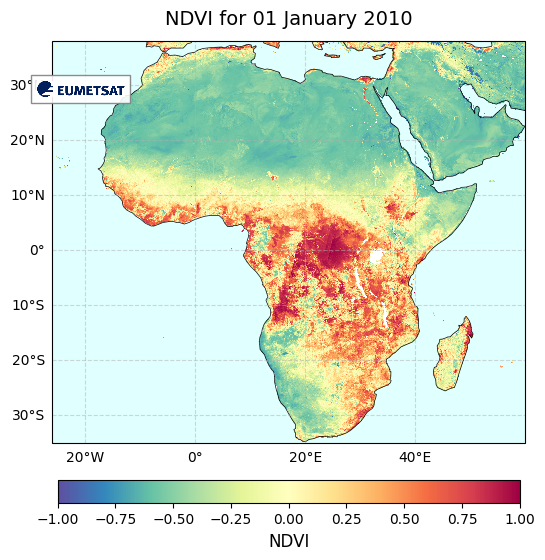

In [15]:
fig, ax = plot_ndvi_africa(ds_ndvi, var='NDVI')

## Mobility Data Cleaning

In [19]:
spatial_units = Path("/home/kzakir/dvcube/test/data/mobility_data/spatial_units.geosjon")
spatial_units = gpd.read_file(spatial_units)
print(spatial_units)

                   id                  name zone_category  \
0     SEN.1.1.1-rural           Dakar-rural         rural   
1    SEN.10.1.1-rural           Mbane-rural         rural   
2    SEN.10.1.2-rural  Ndiaye Mberess-rural         rural   
3    SEN.10.2.1-rural         Cas Cas-rural         rural   
4    SEN.10.2.2-rural   Gamadji Sarre-rural         rural   
..                ...                   ...           ...   
146          city-048                 Thiès         urban   
147          city-049             Tivaouane         urban   
148          city-050                 Touba         urban   
149          city-052             Vélingara         urban   
150          city-054            Ziguinchor         urban   

                                              geometry  
0    MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...  
1    MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...  
2    MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...  
3    MULTIPOLYGON (((-14.37828 16.01092

In [3]:
import glob as glob_module

# Load all mobility CSVs
mobility_dir = Path("/home/kzakir/dvcube/test/data/mobility_data")
mobility_files = glob_module.glob(str(mobility_dir / "*.csv"))

print(f"Found {len(mobility_files)} mobility CSV files:")

# check if the headers are a mismatch

for file in mobility_files:
    df = pd.read_csv(file)
    # print(f"{file}: {df.columns.tolist()}")


Found 12 mobility CSV files:


In [4]:
all_dfs = []
for file in mobility_files:
    if not os.path.exists(file):
        print(f"File not found: {file}")
        continue
    filename = os.path.basename(file)
    parts = filename.replace(".csv", "").split("_")
    weight_type = parts[0]
    subset_type = parts[1]
    days_span = parts[2]
    df = pd.read_csv(file)
    df.columns = [col.replace("_adj", "") for col in df.columns]
    df["weight_type"] = weight_type
    df["subset_type"] = subset_type
    df["days_span"] = days_span
    all_dfs.append(df)
if all_dfs:
    mobility_df = pd.concat(all_dfs, ignore_index=True)
    print("Combined mobility DataFrame:")
    # print(mobility_df.head())
    print(mobility_df.columns)
    # size of the combined DataFrame
    print(f"Combined DataFrame shape: {mobility_df.shape}")
else:
    print("No mobility data files were loaded.")

Combined mobility DataFrame:
Index(['origin', 'destination', 'HalfMonthIndex', 'N_depart', 'N_return',
       'rate_depart', 'rate_return', 'N_users_observed_depart',
       'N_users_observed_return', 'N_migrants', 'rate_migrants',
       'N_users_observed_stock', 'weight_type', 'subset_type', 'days_span'],
      dtype='str')
Combined DataFrame shape: (17032800, 15)


In [20]:
import re
def norm_spatial_id(id_str):
    if pd.isna(id_str):
        return None
    s = str(id_str).strip().lower()
    s = re.sub(r'\s+', '', s)
    s = s.replace("_1-rural","").replace("_2-urban","").replace("_2rural","").replace("_1urban","")
    s=s.replace("-rural","").replace("-urban","")
    return s

In [21]:
spatial_units["norm_id"] = spatial_units["id"].apply(norm_spatial_id)
spatial_units[["id", "norm_id"]].head()
spatial_units

,id,name,zone_category,geometry,norm_id
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",sen.1.1.1
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",sen.10.1.1
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",sen.10.1.2
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",sen.10.2.1
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",sen.10.2.2
...,...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",city-048
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",city-049
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",city-050
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",city-052


In [24]:
mobility_df["norm_spatial_id_origin"] = mobility_df["origin"].apply(norm_spatial_id)
mobility_df["norm_spatial_id_destination"] = mobility_df["destination"].apply(norm_spatial_id)
mobility_df[["origin", "norm_spatial_id_origin", "destination", "norm_spatial_id_destination"]].head()

,origin,norm_spatial_id_origin,destination,norm_spatial_id_destination
0,SEN.14.3.1_1-rural,sen.14.3.1,SEN.6.3.2_1-rural,sen.6.3.2
1,SEN.14.3.1_1-rural,sen.14.3.1,SEN.6.3.2_1-rural,sen.6.3.2
2,SEN.14.3.1_1-rural,sen.14.3.1,SEN.6.3.2_1-rural,sen.6.3.2
3,SEN.14.3.1_1-rural,sen.14.3.1,SEN.6.3.2_1-rural,sen.6.3.2
4,SEN.14.3.1_1-rural,sen.14.3.1,SEN.6.3.2_1-rural,sen.6.3.2


In [25]:
# add the names of origin and destination spatial units to the mobility_df based on the normalized IDs. This will help us later when we want to visualize the mobility data on a map.
mobility_df = mobility_df.merge(spatial_units[["norm_id", "name"]], left_on="norm_spatial_id_origin", right_on="norm_id", how="left").rename(columns={"name": "origin_name"}).drop(columns=["norm_id"])
mobility_df = mobility_df.merge(spatial_units[["norm_id", "name"]], left_on="norm_spatial_id_destination", right_on="norm_id", how="left").rename(columns={"name": "destination_name"}).drop(columns=["norm_id"])
mobility_df[["origin", "norm_spatial_id_origin", "origin_name", "destination", "norm_spatial_id_destination", "destination_name"]].head()

,origin,norm_spatial_id_origin,origin_name,destination,norm_spatial_id_destination,destination_name
0,SEN.14.3.1_1-rural,sen.14.3.1,Niaguis-rural,SEN.6.3.2_1-rural,sen.6.3.2,Sabodala-rural
1,SEN.14.3.1_1-rural,sen.14.3.1,Niaguis-rural,SEN.6.3.2_1-rural,sen.6.3.2,Sabodala-rural
2,SEN.14.3.1_1-rural,sen.14.3.1,Niaguis-rural,SEN.6.3.2_1-rural,sen.6.3.2,Sabodala-rural
3,SEN.14.3.1_1-rural,sen.14.3.1,Niaguis-rural,SEN.6.3.2_1-rural,sen.6.3.2,Sabodala-rural
4,SEN.14.3.1_1-rural,sen.14.3.1,Niaguis-rural,SEN.6.3.2_1-rural,sen.6.3.2,Sabodala-rural


In [26]:
mobility_df

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,rate_migrants,N_users_observed_stock,weight_type,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name
0,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.0,0.0,0.000000,0.0,2091.0,2091.0,0.0,0.000000,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
1,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.0,0.0,0.000000,0.0,2090.0,2091.0,0.0,0.000000,2089.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
2,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130401,0.0,0.0,0.000000,0.0,2091.0,2089.0,0.0,0.000000,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
3,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130416,0.0,0.0,0.000000,0.0,2092.0,2091.0,0.0,0.000000,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
4,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130501,0.0,0.0,0.000000,0.0,2100.0,2091.0,0.0,0.000000,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17032795,city-008,city-017,20151001,0.0,0.0,0.000000,0.0,1949.0,1952.0,0.0,0.000000,1949.0,unweighted,A,20days,city-008,city-017,Diaobé,Kébémer
17032796,city-008,city-017,20151016,0.0,0.0,0.000000,0.0,1938.0,1949.0,0.0,0.000000,1945.0,unweighted,A,20days,city-008,city-017,Diaobé,Kébémer
17032797,city-008,city-017,20151101,0.0,0.0,0.000000,0.0,1933.0,1940.0,0.0,0.000000,1933.0,unweighted,A,20days,city-008,city-017,Diaobé,Kébémer
17032798,city-008,city-017,20151116,0.0,0.0,0.000000,0.0,1924.0,1933.0,0.0,0.000000,1928.0,unweighted,A,20days,city-008,city-017,Diaobé,Kébémer


In [9]:
# uniq_origin_ids = mobility_df["norm_spatial_id_origin"].unique()
# uniq_destination_ids = mobility_df["norm_spatial_id_destination"].unique()
# uniq_spatial_ids = spatial_units["norm_id"].unique()

# # are there any matches between spatial_units and mobility_df origin or destination IDs?
# matching_origin_ids = set(uniq_spatial_ids) & set(uniq_origin_ids)
# matching_dest_ids = set(uniq_spatial_ids) & set(uniq_destination_ids)


# print(len(matching_origin_ids))
# print(len(matching_dest_ids))


In [22]:
# store spatial unit as geoparquet with the normalized ID as the index
spatial_units.to_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units.parquet")

In [27]:
mobility_df.to_parquet("/home/kzakir/dvcube/test/data/mobility_data/mobility_data.parquet")

In [28]:
# read the parquet files back to verify
#spatial_units_parquet = gpd.read_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units.parquet")
mobility_df_parquet = pd.read_parquet("/home/kzakir/dvcube/test/data/mobility_data/mobility_data.parquet")
#spatial_units_parquet
mobility_df_parquet.head()

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,rate_migrants,N_users_observed_stock,weight_type,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name
0,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.0,0.0,0.0,0.0,2091.0,2091.0,0.0,0.0,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
1,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.0,0.0,0.0,0.0,2090.0,2091.0,0.0,0.0,2089.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
2,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130401,0.0,0.0,0.0,0.0,2091.0,2089.0,0.0,0.0,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
3,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130416,0.0,0.0,0.0,0.0,2092.0,2091.0,0.0,0.0,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural
4,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130501,0.0,0.0,0.0,0.0,2100.0,2091.0,0.0,0.0,2091.0,unweighted,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural


## Zonal Stats

In [38]:
aggregated = ds.FAPAR.xvec.zonal_stats(
    units.geometry, x_coords= "lon", y_coords="lat", 
    # stats = "mean",
    method="exactextract"
)
aggregated

RuntimeError: Failed to parse geometry.

In [ ]:

f, ax = aggregated.sel(geometry[0], time[0]).xvec.plot()
ax.set_title(f"FAPAR at {pd.to_datetime(selected_time.values).strftime('%d %B %Y')}")


NameError: name 'geometry' is not defined

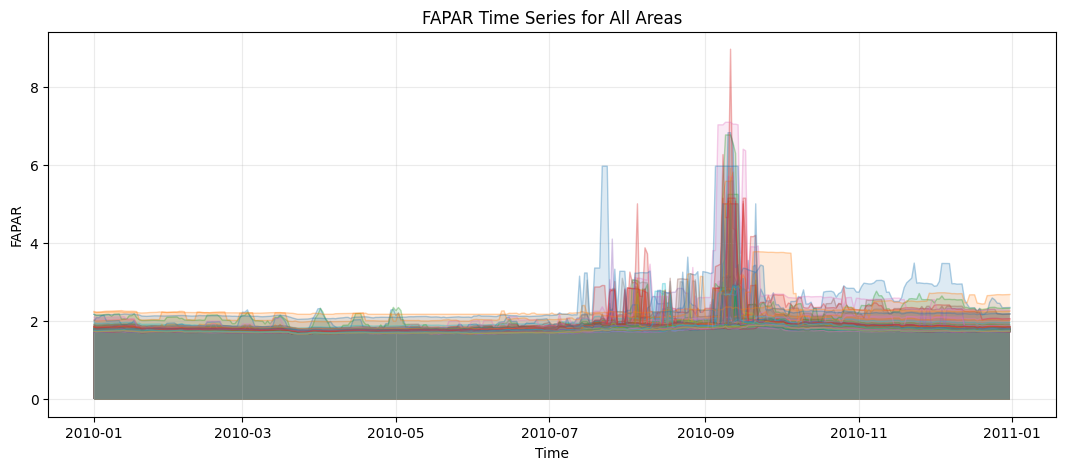

In [21]:
# If you want a time-series view for all areas, use the block below instead.
# It plots one line per geometry/area over time.
#
series = aggregated.FAPAR if hasattr(aggregated, 'FAPAR') else aggregated

fig, ax = plt.subplots(figsize=(13, 5))

# Get dimensions - for DataArray, geometry is the non-time dimension
geom_dim = None
for dim in series.dims:
    if dim != 'time':
        geom_dim = dim
        break

if geom_dim:
    time_vals = pd.to_datetime(series['time'].values)
    n_geoms = series.sizes[geom_dim]
    
    for i in range(n_geoms):
        # Select geometry and take mean over all remaining non-time dims
        data_slice = series.isel({geom_dim: i})
        y_data = data_slice.mean(dim=[d for d in data_slice.dims if d != 'time']).values
        ax.fill_between(time_vals, y_data, alpha=0.15)
        ax.plot(time_vals, y_data, alpha=0.35, linewidth=1.0)

ax.set_title('FAPAR Time Series for All Areas')
ax.set_xlabel('Time')
ax.set_ylabel('FAPAR')
ax.grid(True, alpha=0.25)


In [26]:
# Interactive Plotly dashboard: FAPAR + Mobility variables by spatial unit
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Get FAPAR time series by spatial unit
fapar_series = aggregated.FAPAR if hasattr(aggregated, 'FAPAR') else aggregated
geom_dim = [d for d in fapar_series.dims if d != 'time'][0]
time_vals = pd.to_datetime(fapar_series['time'].values)

# Create unified dataframe: geometry x time for FAPAR + mobility metrics
n_geoms = fapar_series.sizes[geom_dim]
data_dict = {'time': time_vals}

# Add FAPAR for each geometry
for i in range(n_geoms):
    data_slice = fapar_series.isel({geom_dim: i})
    y_data = data_slice.mean(dim=[d for d in data_slice.dims if d != 'time']).values
    data_dict[f'FAPAR_geom_{i}'] = y_data

# Add mobility data if available
if mobility_data:
    # Get first mobility dataset as example (can extend to all)
    first_mobility_key = list(mobility_data.keys())[0]
    mob_df = mobility_data[first_mobility_key]
    
    # Assume first column is spatial unit ID, subsequent columns are values
    for col in mob_df.columns[1:]:
        data_dict[col] = mob_df[col].values[:len(time_vals)] if len(mob_df) > 0 else [np.nan] * len(time_vals)

df_combined = pd.DataFrame(data_dict)

# Get unique variable groups
variable_groups = {
    'FAPAR': [col for col in df_combined.columns if 'FAPAR' in col],
    'Mobility': [col for col in df_combined.columns if col not in ['time'] and 'FAPAR' not in col]
}

# Create interactive figure with buttons for variable selection
fig = go.Figure()

# Add traces for all FAPAR geometries
colors_fapar = px.colors.sequential.Viridis
for i, col in enumerate(variable_groups['FAPAR']):
    fig.add_trace(
        go.Scatter(
            x=df_combined['time'],
            y=df_combined[col],
            name=col.replace('FAPAR_', 'Area '),
            mode='lines',
            line=dict(color=colors_fapar[i % len(colors_fapar)], width=2),
            fill='tozeroy' if i % 2 == 0 else None,
            visible=True if i < 3 else False,  # Show first 3 by default
        )
    )

# Add traces for mobility variables (hidden by default)
colors_mobility = px.colors.qualitative.Plotly
for j, col in enumerate(variable_groups['Mobility']):
    fig.add_trace(
        go.Scatter(
            x=df_combined['time'],
            y=df_combined[col],
            name=col,
            mode='lines',
            line=dict(color=colors_mobility[j % len(colors_mobility)], width=2),
            fill='tozeroy' if j % 2 == 0 else None,
            visible=False,
        )
    )

# Create buttons for variable group selection
buttons = []

# FAPAR button
visibility_fapar = [i < len(variable_groups['FAPAR']) for i in range(len(fig.data))]
buttons.append(
    dict(
        label='FAPAR (Climate)',
        method='update',
        args=[{'visible': visibility_fapar},
              {'title.text': 'FAPAR Time Series by Area', 'yaxis.title': 'FAPAR'}]
    )
)

# Mobility button
visibility_mobility = [i >= len(variable_groups['FAPAR']) for i in range(len(fig.data))]
buttons.append(
    dict(
        label='Mobility Data',
        method='update',
        args=[{'visible': visibility_mobility},
              {'title.text': 'Mobility Metrics by Area', 'yaxis.title': 'Mobility Value'}]
    )
)

# All data button
buttons.append(
    dict(
        label='Show All',
        method='update',
        args=[{'visible': [True] * len(fig.data)},
              {'title.text': 'FAPAR + Mobility Data', 'yaxis.title': 'Value'}]
    )
)

# Update layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.0,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ],
    title='FAPAR Time Series by Area',
    xaxis_title='Time',
    yaxis_title='FAPAR',
    hovermode='x unified',
    template='plotly_white',
    height=600,
    width=1400,
)

fig.show()


In [28]:
# Advanced dashboard: Interactive map + time series with spatial unit selection
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Prepare geospatial data for map
geom_vals = spatial_units.geometry.dropna()
geom_vals_clean = geom_vals[~geom_vals.is_empty].reset_index(drop=True)
n_units = len(geom_vals_clean)

# Create centroids for map markers
centroids = [geom.centroid for geom in geom_vals_clean]
lats = [c.y for c in centroids]
lons = [c.x for c in centroids]

# Create subplots: map on left, time series on right
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'geo'}, {'type': 'xy'}]],
    horizontal_spacing=0.12,
    subplot_titles=('Spatial Units Map', 'Time Series - Click Unit on Map')
)

# Get FAPAR data
fapar_series = aggregated.FAPAR if hasattr(aggregated, 'FAPAR') else aggregated
geom_dim = [d for d in fapar_series.dims if d != 'time'][0]
time_vals = pd.to_datetime(fapar_series['time'].values)

# Calculate mean FAPAR for each unit (for color coding on map)
fapar_means = []
for i in range(min(n_units, fapar_series.sizes[geom_dim])):
    data_slice = fapar_series.isel({geom_dim: i})
    y_data = data_slice.mean(dim=[d for d in data_slice.dims if d != 'time']).values
    fapar_means.append(float(np.mean(y_data)))

# Add scatter points on map
fig.add_trace(
    go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='markers',
        marker=dict(
            size=12,
            color=fapar_means,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='Mean FAPAR', x=0.46, len=0.7),
            line=dict(width=1, color='white')
        ),
        text=[f'Unit {i}: FAPAR={v:.3f}' for i, v in enumerate(fapar_means)],
        hoverinfo='text',
        customdata=list(range(n_units)),
    ),
    row=1, col=1
)

# Add initial time series for first unit
data_slice_0 = fapar_series.isel({geom_dim: 0})
y_data_0 = data_slice_0.mean(dim=[d for d in data_slice_0.dims if d != 'time']).values

fig.add_trace(
    go.Scatter(
        x=time_vals,
        y=y_data_0,
        mode='lines+markers',
        name='Unit 0',
        line=dict(color='blue', width=3),
        fill='tozeroy',
        fillcolor='rgba(0, 0, 255, 0.2)',
        hovertemplate='<b>Unit 0</b><br>%{x|%Y-%m-%d}<br>FAPAR: %{y:.3f}<extra></extra>'
    ),
    row=1, col=2
)

# Update map layout
fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='rgb(243, 243, 243)',
    coastlinecolor='rgb(204, 204, 204)',
    showlakes=True,
    lakecolor='rgb(200, 220, 255)',
    row=1, col=1
)

# Update axes
fig.update_xaxes(title_text='Time', row=1, col=2)
fig.update_yaxes(title_text='FAPAR', row=1, col=2)

# Update overall layout
fig.update_layout(
    title_text='Interactive Spatial Unit Explorer: Map + Time Series',
    height=700,
    width=1600,
    hovermode='closest',
    template='plotly_white',
    showlegend=True,
)

fig.show()

print(f"\n✓ Created interactive dashboard with {n_units} spatial units")
print(f"  Time range: {time_vals[0].date()} to {time_vals[-1].date()}")
print(f"  Mean FAPAR range: {min(fapar_means):.3f} to {max(fapar_means):.3f}")



✓ Created interactive dashboard with 151 spatial units
  Time range: 2010-01-01 to 2010-12-31
  Mean FAPAR range: 1.727 to 2.407


In [31]:
# Complete dashboard: Map view + Time series + Variable selection + Unit filtering
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Creating comprehensive interactive dashboard...")

# Prepare FAPAR data
fapar_series = aggregated.FAPAR if hasattr(aggregated, 'FAPAR') else aggregated
geom_dim = [d for d in fapar_series.dims if d != 'time'][0]
time_vals = pd.to_datetime(fapar_series['time'].values)
n_geoms = fapar_series.sizes[geom_dim]

# Prepare spatial units
geom_vals = spatial_units.geometry.dropna()
geom_vals_clean = geom_vals[~geom_vals.is_empty].reset_index(drop=True)
n_units = min(len(geom_vals_clean), n_geoms)

# Calculate map data
centroids = [geom.centroid for geom in geom_vals_clean[:n_units]]
lats = [c.y for c in centroids]
lons = [c.x for c in centroids]

fapar_means = []
unit_ids = list(range(n_units))

for i in range(n_units):
    data_slice = fapar_series.isel({geom_dim: i})
    y_data = data_slice.mean(dim=[d for d in data_slice.dims if d != 'time']).values
    fapar_means.append(float(np.mean(y_data)))

# Create figure with subplots
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{'type': 'geo', 'rowspan': 2}, {'type': 'xy'}],
        [None, {'type': 'xy'}]
    ],
    horizontal_spacing=0.15,
    vertical_spacing=0.15,
    subplot_titles=('Spatial Units Map (Color = Mean FAPAR)', 'FAPAR Time Series', 'Mobility Metrics')
)

# Track trace indices
map_trace_idx = 0  # Map is first trace (index 0)
fapar_start_idx = 1  # FAPAR traces start at index 1
mobility_start_idx = None

# Add map trace
fig.add_trace(
    go.Scattergeo(
        lon=lons,
        lat=lats,
        mode='markers',
        marker=dict(
            size=10,
            color=fapar_means,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='Mean FAPAR', x=0.45, len=0.9, y=0.5),
            line=dict(width=1, color='white'),
            opacity=0.8
        ),
        text=[f'Unit {i}: Mean FAPAR={v:.3f}' for i, v in enumerate(fapar_means)],
        hoverinfo='text',
        customdata=unit_ids,
        name='Units',
    ),
    row=1, col=1
)

# Add FAPAR time series (first unit visible)
for i in range(min(5, n_units)):  # Show up to 5 traces for performance
    data_slice = fapar_series.isel({geom_dim: i})
    y_data = data_slice.mean(dim=[d for d in data_slice.dims if d != 'time']).values
    
    fig.add_trace(
        go.Scatter(
            x=time_vals,
            y=y_data,
            name=f'Unit {i}',
            mode='lines',
            line=dict(width=2),
            visible=True if i == 0 else False,
            fill='tozeroy' if i == 0 else None,
            hovertemplate='%{x|%Y-%m-%d}<br>FAPAR: %{y:.3f}<extra></extra>'
        ),
        row=1, col=2
    )

# Add mobility data if available
if mobility_data:
    mobility_start_idx = len(fig.data)
    first_mobility_key = list(mobility_data.keys())[0]
    mob_df = mobility_data[first_mobility_key]
    
    for col_idx, col in enumerate(mob_df.columns[1:4]):  # Show first 3 mobility columns
        mob_vals = mob_df[col].values[:len(time_vals)]
        hover_text = f'%{{x|%Y-%m-%d}}<br>{col}: %{{y:.2f}}<extra></extra>'
        
        fig.add_trace(
            go.Scatter(
                x=time_vals[:len(mob_vals)],
                y=mob_vals,
                name=f'{col}',
                mode='lines',
                line=dict(width=2),
                visible=True if col_idx == 0 else False,
                fill='tozeroy' if col_idx == 0 else None,
                hovertemplate=hover_text
            ),
            row=2, col=2
        )

# Update map layout
fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='rgb(243, 243, 243)',
    coastlinecolor='rgb(204, 204, 204)',
    showlakes=True,
    lakecolor='rgb(200, 220, 255)',
    row=1, col=1
)

# Update axes
fig.update_xaxes(title_text='Time', row=1, col=2)
fig.update_yaxes(title_text='FAPAR', row=1, col=2)
fig.update_xaxes(title_text='Time', row=2, col=2)
fig.update_yaxes(title_text='Mobility Value', row=2, col=2)

# Create button for unit selection (simpler logic)
unit_buttons = []
n_fapar_traces = len(fig.data) - 1  # Subtract map
max_units_selectable = min(10, n_fapar_traces)

for unit_idx in range(max_units_selectable):
    visibility = [True] + [False] * (len(fig.data) - 1)  # Keep map visible, hide all traces
    visibility[fapar_start_idx + unit_idx] = True  # Show only this FAPAR trace
    
    if mobility_start_idx is not None:
        visibility[mobility_start_idx] = True  # Show first mobility trace
    
    unit_buttons.append(
        dict(
            label=f'Unit {unit_idx}',
            method='update',
            args=[{'visible': visibility}]
        )
    )

# Update layout with buttons and title
fig.update_layout(
    updatemenus=[
        dict(
            buttons=unit_buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.52,
            xanchor='left',
            y=1.0,
            yanchor='top',
            bgcolor='rgba(240, 240, 240, 0.9)',
            bordercolor='gray',
            borderwidth=1
        )
    ],
    title_text='<b>Integrated Climate + Mobility Dashboard</b><br><sub>Select units from map or dropdown | Showing FAPAR (top) + Mobility (bottom)</sub>',
    height=900,
    width=1600,
    hovermode='x unified',
    template='plotly_white',
    showlegend=True,
    legend=dict(x=0.52, y=0.5)
)

fig.show()

print(f"\n✓ Created comprehensive dashboard:")
print(f"  • {n_units} spatial units mapped and selectable")
print(f"  • Time range: {time_vals[0].date()} to {time_vals[-1].date()} ({len(time_vals)} days)")
print(f"  • FAPAR mean: {np.mean(fapar_means):.3f} ± {np.std(fapar_means):.3f}")
print(f"  • Mobility datasets loaded: {', '.join(list(mobility_data.keys())[:3])}")
print(f"  • Use unit selector dropdown to filter spatial units")


Creating comprehensive interactive dashboard...



✓ Created comprehensive dashboard:
  • 151 spatial units mapped and selectable
  • Time range: 2010-01-01 to 2010-12-31 (365 days)
  • FAPAR mean: 1.813 ± 0.117
  • Mobility datasets loaded: unweighted_A_20days, unweighted_A_30days, unweighted_A_60days
  • Use unit selector dropdown to filter spatial units
